In [15]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle
import os


from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

import statsmodels.api as sm
import pmdarima as pm


In [16]:
#with open("/glade/work/stevenxu/FAIR_models/fair_arima_extension.pkl", "rb") as f_in:
    #f = pickle.load(f_in)

In [17]:
with open("/glade/work/stevenxu/FAIR_models/fair_arima_clipNegative_extension.pkl", "rb") as f_in:
    f = pickle.load(f_in)

In [18]:
fancy_titles = {
    'high-extension': 'High extension',
    'medium-extension': 'Medium extension',
    'medium-overshoot': 'Medium overshoot',
    'low': 'Low',
    'verylow-overshoot': 'Verylow overshoot',
    'ARIMA_mean': 'ARIMA mean',
    'ARIMA_low': 'ARIMA low',
    'ARIMA_high': 'ARIMA high',
}

colors = {
    'high-extension': '#800000',   # dark red
    'high-overshoot': '#ff0000',   # bright red
    'medium-extension': '#c87820', # orange-brown
    'medium-overshoot': '#d3a640', # gold
    'low': '#098740',              # green
    'verylow': '#0080d0',          # blue
    'verylow-overshoot': '#100060',# navy
    'ARIMA_mean': '#6a0dad',       # royal purple (distinct mean)
    'ARIMA_low': '#9370db',        # lighter purple (low)
    'ARIMA_high': '#4b0082',       # indigo (high)
}


In [19]:
weights_51yr = np.ones(52)
weights_51yr[0] = 0.5
weights_51yr[-1] = 0.5

# removing for plotting
scenarios = [
    "high-extension",
    "medium-overshoot",
    "medium-extension",
    "low", 
    "verylow-overshoot", 
    'ARIMA_low', 'ARIMA_mean',  'ARIMA_high'
]



# Temperature

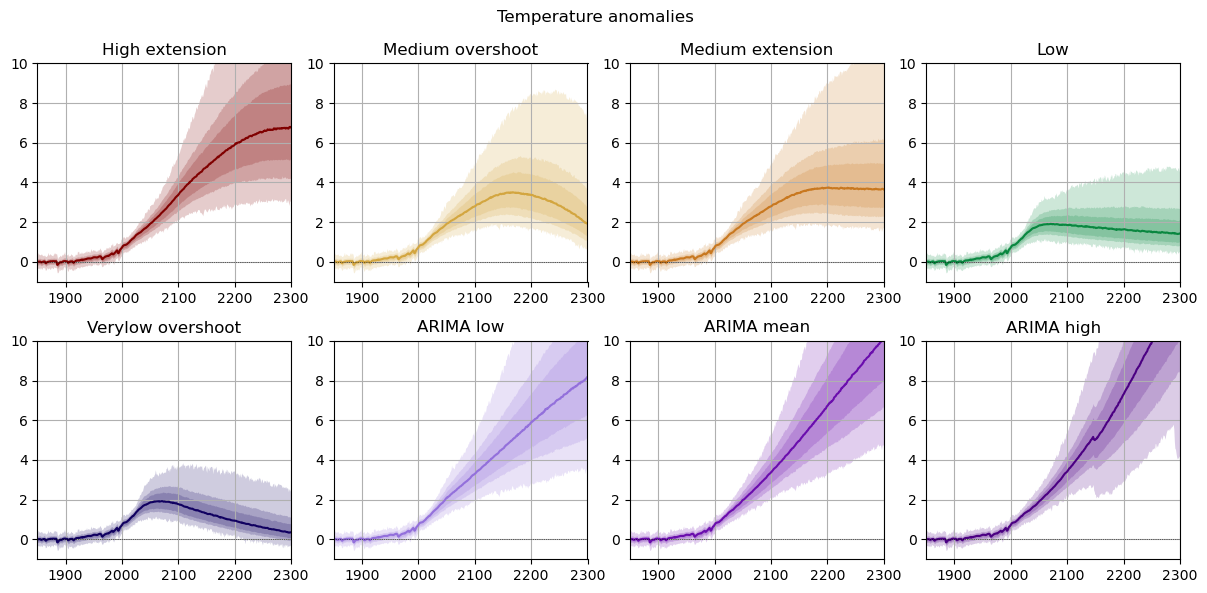

In [20]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timebounds,
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[1],
                axis=1,
            ),
            color=colors[scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timebounds,
        np.median(
            f.temperature.loc[dict(scenario=scenario, layer=0)]
            - np.average(
                f.temperature.loc[
                    dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                ],
                weights=weights_51yr,
                axis=0
            ),
            axis=1,
        ),
        color=colors[scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].set_ylim(-1, 10)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[scenarios[i]])
    ax[i // 4, i % 4].grid()
    
pl.suptitle("Temperature anomalies")
fig.tight_layout()

# Emission

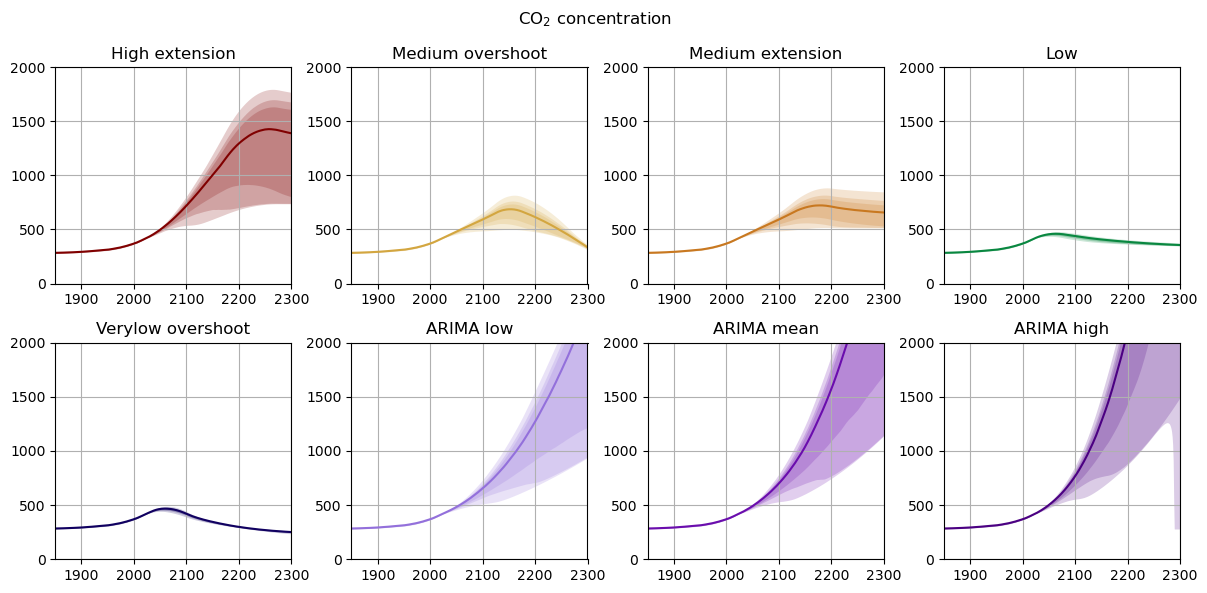

In [21]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timebounds,
            np.percentile(
                f.concentration.loc[dict(scenario=scenario, specie='CO2')],
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.concentration.loc[dict(scenario=scenario, specie='CO2')],
                pp[1],
                axis=1,
            ),
            color=colors[scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timebounds,
        np.median(
            f.concentration.loc[dict(scenario=scenario, specie='CO2')],
            axis=1,
        ),
        color=colors[scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].set_ylim(0, 2000)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[scenarios[i]])
    ax[i // 4, i % 4].grid()
    
pl.suptitle("CO$_2$ concentration")
fig.tight_layout()

# Forcing

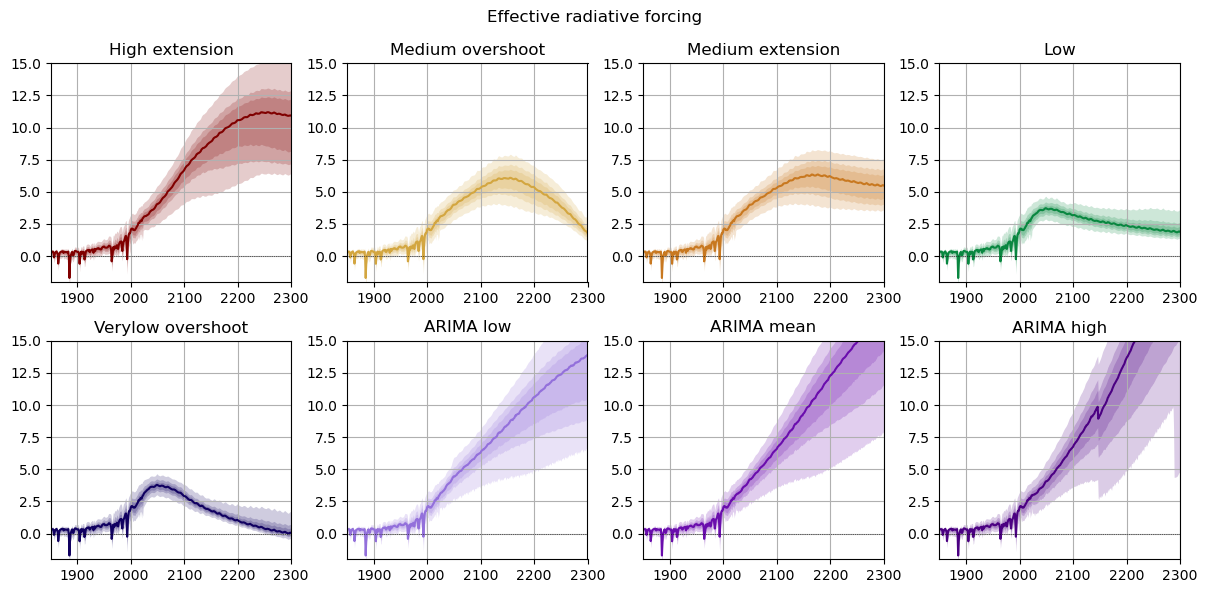

In [22]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timebounds,
            np.percentile(
                f.forcing_sum.loc[dict(scenario=scenario)],
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.forcing_sum.loc[dict(scenario=scenario)],
                pp[1],
                axis=1,
            ),
            color=colors[scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timebounds,
        np.median(
            f.forcing_sum.loc[dict(scenario=scenario)],
            axis=1,
        ),
        color=colors[scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].set_ylim(-2, 15)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[scenarios[i]])
    ax[i // 4, i % 4].grid()

pl.suptitle("Effective radiative forcing")
fig.tight_layout()

In [23]:
f.species

['CO2 FFI',
 'CO2 AFOLU',
 'CO2',
 'CH4',
 'N2O',
 'Sulfur',
 'BC',
 'OC',
 'NH3',
 'NOx',
 'VOC',
 'CO',
 'CFC-11',
 'CFC-12',
 'CFC-113',
 'CFC-114',
 'CFC-115',
 'HCFC-22',
 'HCFC-141b',
 'HCFC-142b',
 'CCl4',
 'CHCl3',
 'CH2Cl2',
 'CH3Cl',
 'CH3CCl3',
 'CH3Br',
 'Halon-1211',
 'Halon-1301',
 'Halon-2402',
 'CF4',
 'C2F6',
 'C3F8',
 'c-C4F8',
 'C4F10',
 'C5F12',
 'C6F14',
 'C7F16',
 'C8F18',
 'NF3',
 'SF6',
 'SO2F2',
 'HFC-125',
 'HFC-134a',
 'HFC-143a',
 'HFC-152a',
 'HFC-227ea',
 'HFC-23',
 'HFC-236fa',
 'HFC-245fa',
 'HFC-32',
 'HFC-365mfc',
 'HFC-4310mee',
 'Solar',
 'Volcanic',
 'Aerosol-radiation interactions',
 'Aerosol-cloud interactions',
 'Ozone',
 'Light absorbing particles on snow and ice',
 'Stratospheric water vapour',
 'Land use',
 'Equivalent effective stratospheric chlorine']

# Specie Emissions

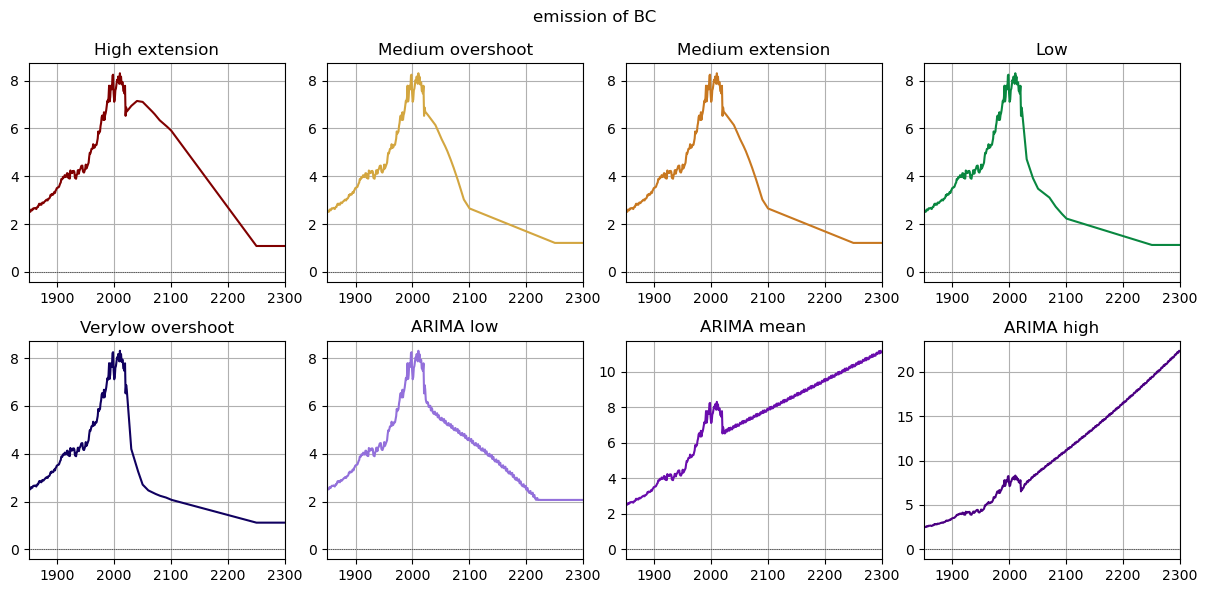

In [30]:
specie = 'BC'

fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timepoints,
            np.percentile(
                f.emissions.loc[dict(scenario=scenario, specie = specie)],
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.emissions.loc[dict(scenario=scenario, specie = specie)],
                pp[1],
                axis=1,
            ),
            color=colors[scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timepoints,
        np.median(
            f.emissions.loc[dict(scenario=scenario, specie = specie)],
            axis=1,
        ),
        color=colors[scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    #ax[i // 4, i % 4].set_ylim(-2, 15)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[scenarios[i]])
    ax[i // 4, i % 4].grid()

pl.suptitle(f"emission of {specie}")
fig.tight_layout()

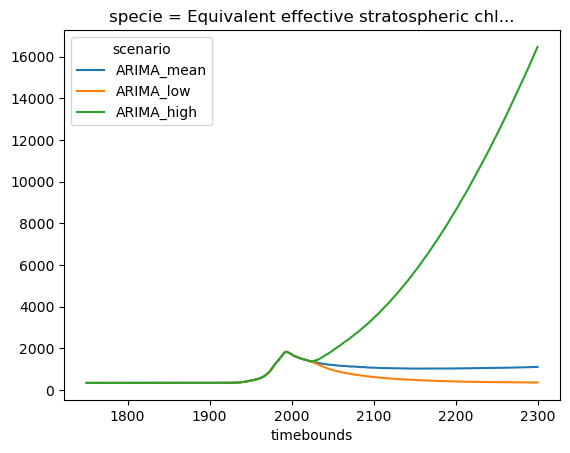

In [26]:
f.concentration.sel(specie = 'Equivalent effective stratospheric chlorine').isel(scenario = slice(-3,None)).mean(dim = 'config').plot(hue = 'scenario')

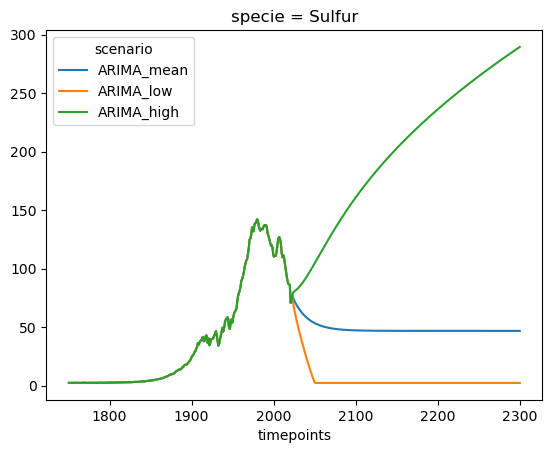

In [27]:
f.emissions.sel(specie = 'Sulfur').isel(scenario = slice(-3,None)).mean(dim = 'config').plot(hue = 'scenario')

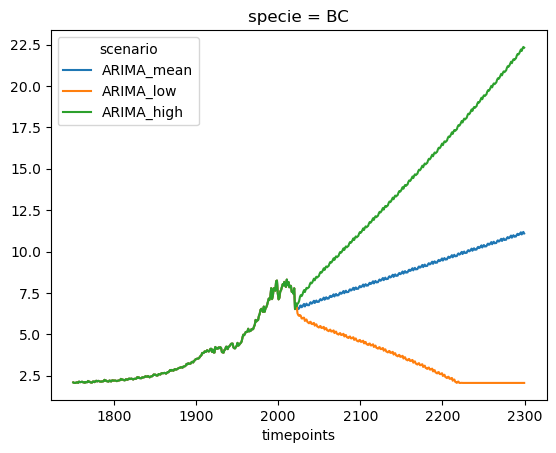

In [28]:
f.emissions.sel(specie = 'BC').isel(scenario = slice(-3,None)).mean(dim = 'config').plot(hue = 'scenario')